In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.ndimage import gaussian_filter1d

import os 
import sys
from format_waveform_data import get_spike_times
sys.path.append("..//behavior/")
from format_behavior_data import load_behavior_data, get_caches_refined, get_visits_refined
sys.path.append("..//utils/")
import color_utils, helpers
from load_matlab_data import loadmat_sbx

In [2]:
''' File Paths '''
root_dir = "Z:/Isabel/data/hpc_implants/"
save_figs_dir = f"../figures/basic_neural_analysis/"
data_file = f"{root_dir}stim_session_data.npy"
session_info_file = f"{root_dir}good_sessions.xlsx"


''' Data params '''
bird = 'SLV132' # update as needed
data_dict = np.load(data_file, allow_pickle=True).item()
session_list = data_dict[bird]['all_sessions']

# collect sessions with pose tracking & ephys
behavior_sessions = []
for session_id in session_list:
    preprocessed_data = data_dict[bird][session_id]['preprocessed_data']
    if ('behavior' in preprocessed_data) & ('ephys' in preprocessed_data):
        behavior_sessions.append(session_id)

In [3]:
session_id = '250326'

In [4]:
print(f'collecting cache-aligned data for {bird}_{session_id}')

''' Get the file params '''
session_dir = f"{root_dir}{bird}/{bird}_{session_id}/"
data_dir = f"{session_dir}/behavior_data/"
pred_date = data_dict[bird][session_id]['pred_date']
ephys_id = data_dict[bird][session_id]['ephys_id']
ephys_folder= f"{root_dir}{bird}/{bird}_{session_id}/{bird}_{ephys_id}/"
for folder in sorted(os.listdir(ephys_folder)):
    if 'kilosort4' in folder:
        for file in sorted(os.listdir(f"{ephys_folder}{folder}")):
            if 'waveformStruct' in file:
                ks_dir = f"{bird}_{ephys_id}/{folder}/"

collecting cache-aligned data for SLV132_250326


In [5]:
''' Load the frame times '''
sampling_rate = 30000 # intan
framet_raw = np.load(f'{data_dir}frame_times.npy')
framet_raw = np.squeeze(framet_raw)
dt = np.unique(np.round(np.diff(framet_raw), 2))
dt = dt[0]

# align so that 0 is the video start time
start_t = framet_raw[0]
frame_t = framet_raw - start_t
frame_samples = np.append(frame_t, frame_t[-1] + dt)*sampling_rate
n_frames = frame_t.shape[0]

In [24]:
''' Load/format the neural data '''
# get the cell IDs and raw spike times
good_clusters, spike_id, spike_samp_raw = get_spike_times(session_dir, ks_dir=ks_dir)
n_cells = good_clusters.shape[0]

# keep only spikes from within the session
spike_t = spike_samp_raw - start_t*sampling_rate
spike_id = spike_id[(spike_t >= 0) & (spike_t <= frame_samples[-1])]
spike_t = spike_t[(spike_t >= 0) & (spike_t <= frame_samples[-1])]

# spikes per frame and spike bool
spike_frame = np.zeros((n_cells, n_frames))
i = -1
for c_idx, cell in enumerate(good_clusters):
    i += 1
    spk_times = spike_t[spike_id==cell]       
    spike_frame[i], _ = np.histogram(spk_times, frame_samples)
spike_bool = spike_frame.astype(bool)

# instantaneous firing rate
inst_firing_rate = spike_frame/dt

# session average firing rate
waveform_props = data_dict[bird][session_id]['waveform_props']
log_fr = waveform_props[2]
avg_firing_rate = 10**log_fr

In [7]:
''' Load and format behavior data '''
data_dir = f"{root_dir}{bird}/{bird}_{session_id}/behavior_data/"
seed_struct, count_data = load_behavior_data(data_dir)
cache_onsets, cache_offsets, cache_ids = get_caches_refined(count_data, seed_struct, n_frames)
visit_onsets, visit_offsets, visit_ids = get_visits_refined(count_data, n_frames)
n_caches = cache_onsets.shape[0]
n_visits = visit_onsets.shape[0]

Z:/Isabel/data/hpc_implants/SLV132/SLV132_250326/behavior_data/annotatedSeeds.mat


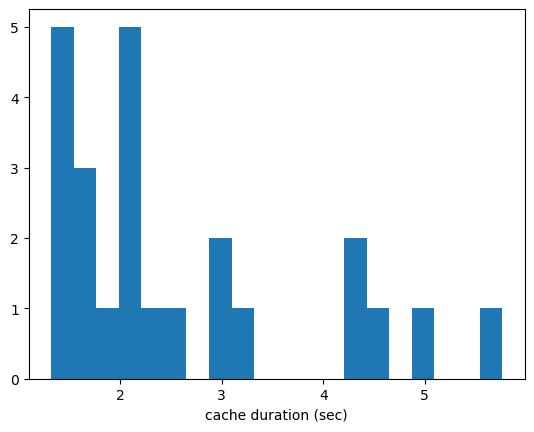

In [13]:
# plot cache durations
cache_dur = cache_offsets - cache_onsets
plt.hist(cache_dur/50, bins=20)
plt.xlabel('cache duration (sec)')
plt.show()

In [40]:
''' Average neural activity during each visit and cache '''
# account for long caches as in SC, EM 2024
long_thresh = 2 # seconds
long_window = int(long_thresh/2/dt) # frames

# get average activity during cache window
avg_cache = np.zeros((n_cells, n_caches))
for i, (cache_on, cache_off) in enumerate(zip(cache_onsets, cache_offsets)):
    if cache_off - cache_on < long_thresh:
        spike_count = np.sum(spike_frame[:, cache_on:cache_off], axis=1)
        occupancy = dt*(cache_off-cache_on)
        avg_cache[:, i] = spike_count/occupancy
    else:
        begin_count = np.sum(spike_frame[:, cache_on:cache_on+long_window], axis=1)
        end_count = np.sum(spike_frame[:, cache_off-long_window:cache_off], axis=1)
        spike_count = begin_count + end_count
        avg_cache[:, i] = spike_count/long_thresh

# get average activity during visit window
avg_visit = np.zeros((n_cells, n_visits))
for i, (visit_on, visit_off) in enumerate(zip(visit_onsets, visit_offsets)):
    avg_visit[:, i] = np.nanmean(spike_frame[:, visit_on:visit_off], axis=1)

# fraction of caches w/ FR > session avg
active_cache = np.zeros_like(avg_cache)
for c_idx in range(n_cells):
    active_cache[c_idx] = avg_cache[c_idx] > avg_firing_rate[c_idx]
active_cache_frac = np.sum(active_cache, axis=1) / n_caches

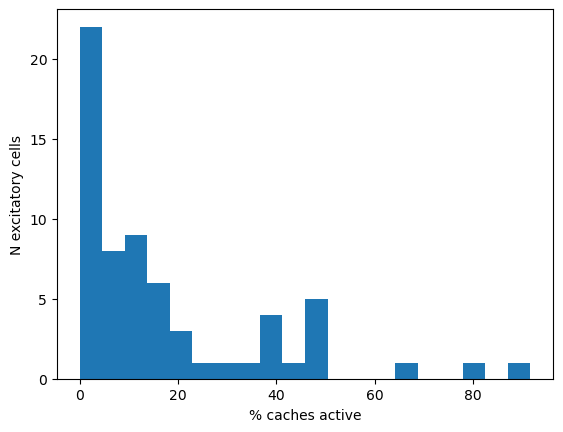

In [43]:
# plot active caches
pct_active = active_cache_frac*100
plt.hist(pct_active, bins=20)
plt.xlabel('% caches active')
plt.ylabel('N excitatory cells')
plt.show()

In [46]:
''' Normalize activity for population analysis '''
# get the baseline rate for each cell (running 30min avg activity)
baseline_window = 30 # minutes
moving_avg_fr = np.zeros_like(inst_firing_rate)
for cell in range(n_cells):
    moving_avg_fr[cell] = helpers.moving_avg(inst_firing_rate[cell], window=baseline_window)

# get the standard deviation (regularize by adding 0.6 Hz)
st_dev_fr = stats.tstd(inst_firing_rate, axis=1) + 0.6
assert st_dev_fr.shape[0] == n_cells

# normalize
norm_fr = inst_firing_rate.copy()
norm_fr -= moving_avg_fr
for cell in range(n_cells):
    norm_fr[cell] /= st_dev_fr[cell]

In [56]:
''' Compute the population activity vectors '''
# collect all the population vectors for this session
visit_vectors_raw = np.zeros((n_cells, n_visits))
for i, (vs, ve) in enumerate(zip(visit_onsets, visit_offsets)):
    visit_vectors_raw[:, i] = np.mean(norm_fr[:, vs:ve], axis=1)

cache_vectors_raw = np.zeros((n_cells, n_caches))    
for i, (cs, ce) in enumerate(zip(cache_onsets, cache_offsets)):
    cache_vectors_raw[:, i] = np.mean(norm_fr[:, cs:ce], axis=1)

# compute avg population vectors for all visits, caches
avg_visit_vector = np.mean(visit_vectors_raw, axis=1, keepdims=True)
avg_cache_vector = np.mean(cache_vectors_raw, axis=1, keepdims=True)

# subtract the means
visit_vectors = visit_vectors_raw - avg_visit_vector
cache_vectors = cache_vectors_raw - avg_cache_vector

In [64]:
np.max(visit_vectors)

8.64757068522574